# 📊 Exploratory Data Analysis (EDA)

## UNSW 2018 IoT Botnet Dataset 9

In this notebook, we will perform a complete EDA (Exploratory Data Analysis) on the UNSW_2018_IoT_Botnet_Dataset_9 dataset.

**About the Dataset:**

- This is a dataset created for Botnet attack detection on IoT (Internet of Things) networks
- Network traffic data has been collected from various IoT devices
- Target variable is **attack** (0 = Normal, 1 = Attack)

**Column Description:**

| Column | Description |
|--------|-------------|
| pkSeqID | Packet Sequence ID |
| stime | Start time |
| flgs | Flags |
| proto | Protocol (TCP/UDP) |
| saddr | Source IP Address |
| sport | Source Port |
| daddr | Destination IP Address |
| dport | Destination Port |
| pkts | Total Packets |
| bytes | Total Bytes |
| state | Connection State |
| dur | Duration |
| mean | Mean packet size |
| stddev | Standard deviation |
| spkts | Source packets |
| dpkts | Destination packets |
| sbytes | Source bytes |
| dbytes | Destination bytes |
| rate | Rate |
| srate | Source rate |
| drate | Destination rate |
| attack | Target: 0=Normal, 1=Attack |
| category | Attack category |
| subcategory | Attack subcategory |

---
## Section 1: Import Required Libraries
Importing all required libraries - pandas, numpy, matplotlib, seaborn, sklearn

Section 1: Import Required Libraries
Importing all required libraries - pandas, numpy, matplotlib, seaborn, sklearn

In [77]:
# ============================
# Section 1: Import Required Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot style
plt.style.use('ggplot')
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")
print(f"   pandas  version : {pd.__version__}")
print(f"   numpy   version : {np.__version__}")

✅ All libraries imported successfully!
   pandas  version : 2.2.2
   numpy   version : 2.0.2


---
## Section 2: Load the Dataset
Loading the dataset. This dataset does not have a header, so column names have been added manually.

In [78]:
# ============================
# Section 2: Load the Dataset
# ============================

# Column names for the UNSW IoT Botnet Dataset (no header in CSV)
col_names = [
    'pkSeqID', 'stime', 'flgs', 'proto',
    'saddr', 'sport', 'daddr', 'dport',
    'pkts', 'bytes', 'state', 'ltime',
    'seq', 'dur', 'mean', 'stddev',
    'smac', 'dmac', 'sum', 'min', 'max',
    'soui', 'doui', 'sco', 'dco',
    'spkts', 'dpkts', 'sbytes', 'dbytes',
    'rate', 'srate', 'drate',
    'attack', 'category', 'subcategory'
]

# Load dataset
FILE_PATH = r'UNSW_2018_IoT_Botnet_Dataset_9.csv'

df = pd.read_csv(FILE_PATH, header=None, names=col_names, low_memory=False)

print(f"✅ Dataset loaded successfully!")
print(f"   Total rows    : {df.shape[0]:,}")
print(f"   Total columns : {df.shape[1]}")
print()
print("--- First 5 rows ---")
df.head()

✅ Dataset loaded successfully!
   Total rows    : 1,000,000
   Total columns : 35

--- First 5 rows ---


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,ltime,seq,dur,mean,stddev,smac,dmac,sum,min,max,soui,doui,sco,dco,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,8000001,1528082590.7597,e g,tcp,192.168.100.149,7564.0000,192.168.100.3,80.0000,6,548,RST,1528082614.2929,252934,23.5333,0.1480,0.0027,NaN,NaN,0.2960,0.1453,0.1507,NaN,NaN,NaN,NaN,4,2,428,120,0.2125,0.1275,0.0425,1,DoS,TCP
1,8000002,1528082590.7597,e g,tcp,192.168.100.149,7565.0000,192.168.100.3,80.0000,6,548,RST,1528082614.2929,252935,23.5333,0.1480,0.0027,NaN,NaN,0.2960,0.1453,0.1507,NaN,NaN,NaN,NaN,4,2,428,120,0.2125,0.1275,0.0425,1,DoS,TCP
2,8000003,1528082590.7597,e g,tcp,192.168.100.149,7570.0000,192.168.100.3,80.0000,6,548,RST,1528082614.2930,252936,23.5333,0.1360,0.0147,NaN,NaN,0.2720,0.1213,0.1507,NaN,NaN,NaN,NaN,4,2,428,120,0.2125,0.1275,0.0425,1,DoS,TCP
3,8000004,1528082590.7597,e g,tcp,192.168.100.149,7571.0000,192.168.100.3,80.0000,6,548,RST,1528082614.2930,252937,23.5333,0.1360,0.0147,NaN,NaN,0.2720,0.1213,0.1507,NaN,NaN,NaN,NaN,4,2,428,120,0.2125,0.1275,0.0425,1,DoS,TCP
4,8000005,1528082590.7597,e g,tcp,192.168.100.149,7574.0000,192.168.100.3,80.0000,6,548,RST,1528082614.2930,252938,23.5333,0.1360,0.0147,NaN,NaN,0.2720,0.1213,0.1507,NaN,NaN,NaN,NaN,4,2,428,120,0.2125,0.1275,0.0425,1,DoS,TCP


In [79]:
# View the last 5 rows
print("--- Last 5 rows ---")
df.tail()

--- Last 5 rows ---


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,ltime,seq,dur,mean,stddev,smac,dmac,sum,min,max,soui,doui,sco,dco,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
999995,8999996,1528082799.6553,e s,tcp,192.168.100.150,5701.0000,192.168.100.6,80.0000,5,676,RST,1528082858.5779,8174,58.9226,0.0121,0.0210,NaN,NaN,0.0484,0.0000,0.0484,NaN,NaN,NaN,NaN,4,1,616,60,0.0679,0.0509,0.0000,1,DoS,TCP
999996,8999997,1528082799.6553,e s,tcp,192.168.100.150,5706.0000,192.168.100.6,80.0000,4,616,REQ,1528082858.5779,8175,58.9226,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,4,0,616,0,0.0509,0.0509,0.0000,1,DoS,TCP
999997,8999998,1528082799.6553,e s,tcp,192.168.100.150,5707.0000,192.168.100.6,80.0000,4,616,REQ,1528082858.5780,8176,58.9226,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,4,0,616,0,0.0509,0.0509,0.0000,1,DoS,TCP
999998,8999999,1528082799.6553,e s,tcp,192.168.100.150,5710.0000,192.168.100.6,80.0000,4,616,REQ,1528082858.5780,8177,58.9226,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,4,0,616,0,0.0509,0.0509,0.0000,1,DoS,TCP
999999,9000000,1528082799.6553,e s,tcp,192.168.100.150,5711.0000,192.168.100.6,80.0000,4,616,REQ,1528082858.5780,8178,58.9226,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,4,0,616,0,0.0509,0.0509,0.0000,1,DoS,TCP


---
## Section 3: Dataset Overview
Dataset shape, column names, data types, and general information are being inspected.

In [80]:
# ============================
# Section 3: Dataset Overview
# ============================

print("=" * 55)
print("          DATASET OVERVIEW")
print("=" * 55)
print(f"Shape (rows × columns) : {df.shape}")
print(f"Total rows             : {df.shape[0]:,}")
print(f"Total columns          : {df.shape[1]}")
print()
print("--- Column Names ---")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

          DATASET OVERVIEW
Shape (rows × columns) : (1000000, 35)
Total rows             : 1,000,000
Total columns          : 35

--- Column Names ---
   1. pkSeqID
   2. stime
   3. flgs
   4. proto
   5. saddr
   6. sport
   7. daddr
   8. dport
   9. pkts
  10. bytes
  11. state
  12. ltime
  13. seq
  14. dur
  15. mean
  16. stddev
  17. smac
  18. dmac
  19. sum
  20. min
  21. max
  22. soui
  23. doui
  24. sco
  25. dco
  26. spkts
  27. dpkts
  28. sbytes
  29. dbytes
  30. rate
  31. srate
  32. drate
  33. attack
  34. category
  35. subcategory


In [81]:
# Data types and non-null count
print("--- Data Types & Non-Null Count ---")
df.info()

--- Data Types & Non-Null Count ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   pkSeqID      1000000 non-null  int64  
 1   stime        1000000 non-null  float64
 2   flgs         1000000 non-null  object 
 3   proto        1000000 non-null  object 
 4   saddr        1000000 non-null  object 
 5   sport        999966 non-null   float64
 6   daddr        1000000 non-null  object 
 7   dport        999966 non-null   float64
 8   pkts         1000000 non-null  int64  
 9   bytes        1000000 non-null  int64  
 10  state        1000000 non-null  object 
 11  ltime        1000000 non-null  float64
 12  seq          1000000 non-null  int64  
 13  dur          1000000 non-null  float64
 14  mean         1000000 non-null  float64
 15  stddev       1000000 non-null  float64
 16  smac         0 non-null        float64
 17  dmac       

In [82]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns ({len(num_cols)})  : {num_cols}")
print()
print(f"Categorical Columns ({len(cat_cols)}) : {cat_cols}")

Numerical Columns (28)  : ['pkSeqID', 'stime', 'sport', 'dport', 'pkts', 'bytes', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack']

Categorical Columns (7) : ['flgs', 'proto', 'saddr', 'daddr', 'state', 'category', 'subcategory']


---
## Section 4: Missing Values Analysis
Checking the number of missing values in each column and visualizing them.

In [83]:
# ============================
# Section 4: Missing Values Analysis
# ============================

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("--- Missing Values Summary ---")
print(missing_df[missing_df['Missing Count'] > 0])
print()

total_missing = missing.sum()
print(f"Total Missing Values : {total_missing:,}")
if total_missing == 0:
    print("✅ No missing values found!")

--- Missing Values Summary ---
       Missing Count  Missing %
soui         1000000   100.0000
dmac         1000000   100.0000
smac         1000000   100.0000
sco          1000000   100.0000
dco          1000000   100.0000
doui         1000000   100.0000
sport             34     0.0034
dport             34     0.0034

Total Missing Values : 6,000,068


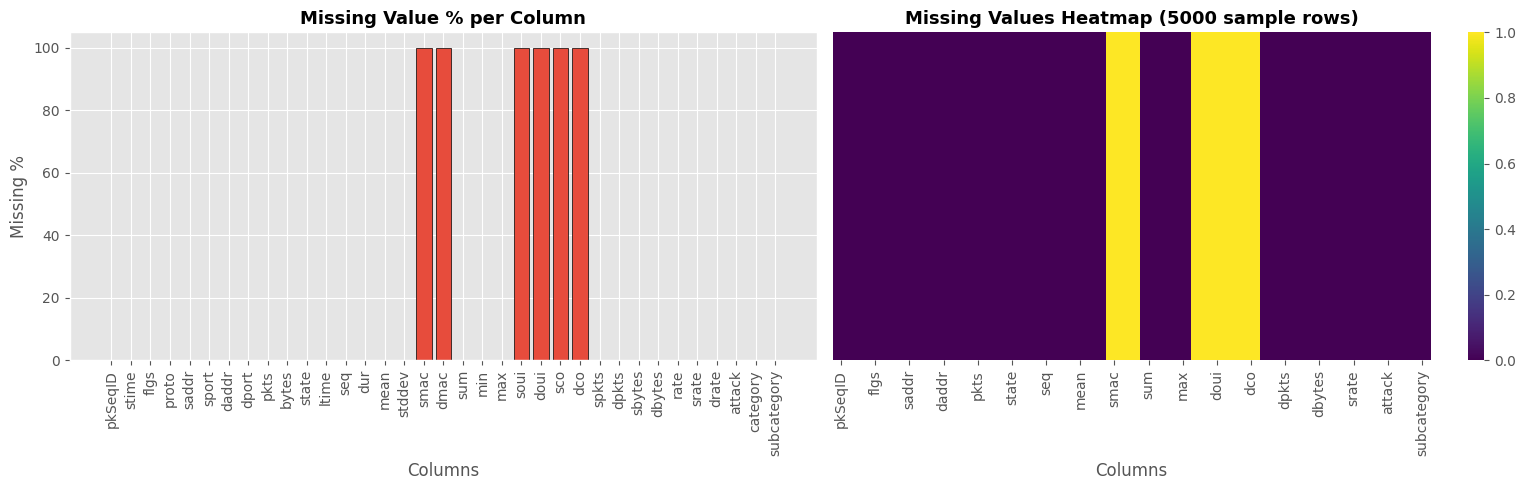

In [84]:
# Missing values bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: All columns missing bar chart ---
missing_pct_all = (df.isnull().sum() / len(df)) * 100
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_pct_all]
axes[0].bar(missing_pct_all.index, missing_pct_all.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Missing Value % per Column', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Missing %')
axes[0].tick_params(axis='x', rotation=90)
axes[0].axhline(y=0, color='black', linewidth=0.5)

# --- Plot 2: Heatmap (sample) ---
sample_df = df.sample(min(5000, len(df)), random_state=42)
sns.heatmap(sample_df.isnull(), yticklabels=False, cbar=True,
            cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values Heatmap (5000 sample rows)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()

---
## Section 5: Statistical Summary
Statistical summary of numerical features is being inspected - mean, std, min, max, quartiles.

In [85]:
# ============================
# Section 5: Statistical Summary
# ============================

print("--- Numerical Features Statistical Summary ---")
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv'] = (desc['std'] / desc['mean']).abs()  # Coefficient of Variation
print(desc.round(4))
desc

--- Numerical Features Statistical Summary ---
               count            mean         std             min  \
pkSeqID 1000000.0000    8500000.5000 288675.2789    8000001.0000   
stime   1000000.0000 1528082688.7363     48.7704 1528082590.7597   
sport    999966.0000      32737.5751  19043.8456          0.0000   
dport    999966.0000        109.9242   1216.1027          0.0000   
pkts    1000000.0000          4.2896     30.1685          1.0000   
bytes   1000000.0000        651.7068  28409.4902         60.0000   
ltime   1000000.0000 1528082715.9493     59.1509 1528082597.7982   
seq     1000000.0000     176145.1943 116953.4910          1.0000   
dur     1000000.0000         27.2154     16.8441          0.0000   
mean    1000000.0000          0.0951      0.2644          0.0000   
stddev  1000000.0000          0.0869      0.3496          0.0000   
smac          0.0000             NaN         NaN             NaN   
dmac          0.0000             NaN         NaN             NaN   
s

,count,mean,std,min,25%,50%,75%,max,range,cv
pkSeqID,1000000.0000,8500000.5000,288675.2789,8000001.0000,8250000.7500,8500000.5000,8750000.2500,9000000.0000,999999.0000,0.0340
stime,1000000.0000,1528082688.7363,48.7704,1528082590.7597,1528082644.6548,1528082690.6785,1528082747.8845,1528082799.6553,208.8956,0.0000
sport,999966.0000,32737.5751,19043.8456,0.0000,15956.0000,33033.5000,49110.0000,65535.0000,65535.0000,0.5817
dport,999966.0000,109.9242,1216.1027,0.0000,80.0000,80.0000,80.0000,65161.0000,65161.0000,11.0631
pkts,1000000.0000,4.2896,30.1685,1.0000,3.0000,4.0000,6.0000,9810.0000,9809.0000,7.0330
bytes,1000000.0000,651.7068,28409.4902,60.0000,308.0000,548.0000,770.0000,9561657.0000,9561597.0000,43.5924
ltime,1000000.0000,1528082715.9493,59.1509,1528082597.7982,1528082671.3667,1528082727.5507,1528082778.8361,1528082859.0057,261.2074,0.0000
seq,1000000.0000,176145.1943,116953.4910,1.0000,80608.0000,163941.0000,247274.2500,458273.0000,458272.0000,0.6640
dur,1000000.0000,27.2154,16.8441,0.0000,20.2032,27.7816,39.7158,61.4576,61.4576,0.6189
mean,1000000.0000,0.0951,0.2644,0.0000,0.0000,0.0000,0.1337,4.9876,4.9876,2.7795


In [86]:
#Unique values of categorical columns
print("--- Categorical Columns Unique Value Count ---")
for col in cat_cols:
    print(f"\n  [{col}] - {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(10))

--- Categorical Columns Unique Value Count ---

  [flgs] - 4 unique values:
flgs
e s    591461
e      221908
e g    186086
e *       545
Name: count, dtype: int64

  [proto] - 4 unique values:
proto
tcp          999949
arp              34
udp              16
ipv6-icmp         1
Name: count, dtype: int64

  [saddr] - 11 unique values:
saddr
192.168.100.148    253998
192.168.100.147    250767
192.168.100.150    248819
192.168.100.149    245662
192.168.100.3         357
192.168.100.6         167
192.168.100.7         112
192.168.100.5         102
192.168.100.46         12
192.168.100.55          3
Name: count, dtype: int64

  [daddr] - 15 unique values:
daddr
192.168.100.5      251513
192.168.100.7      251318
192.168.100.6      250936
192.168.100.3      245506
192.168.100.147       314
192.168.100.150       154
192.168.100.149       132
192.168.100.148       116
52.64.239.193           4
199.7.83.42             2
Name: count, dtype: int64

  [state] - 6 unique values:
state
REQ    575664

---
## Section 6: Target Variable Distribution
Analyzing the distribution of the target variable `attack` (0=Normal, 1=Attack) and analyzing class imbalance.

--- Target Variable: attack ---
  0 (Normal) :         38  (0.00%)
  1 (Attack) :    999,962  (100.00%)


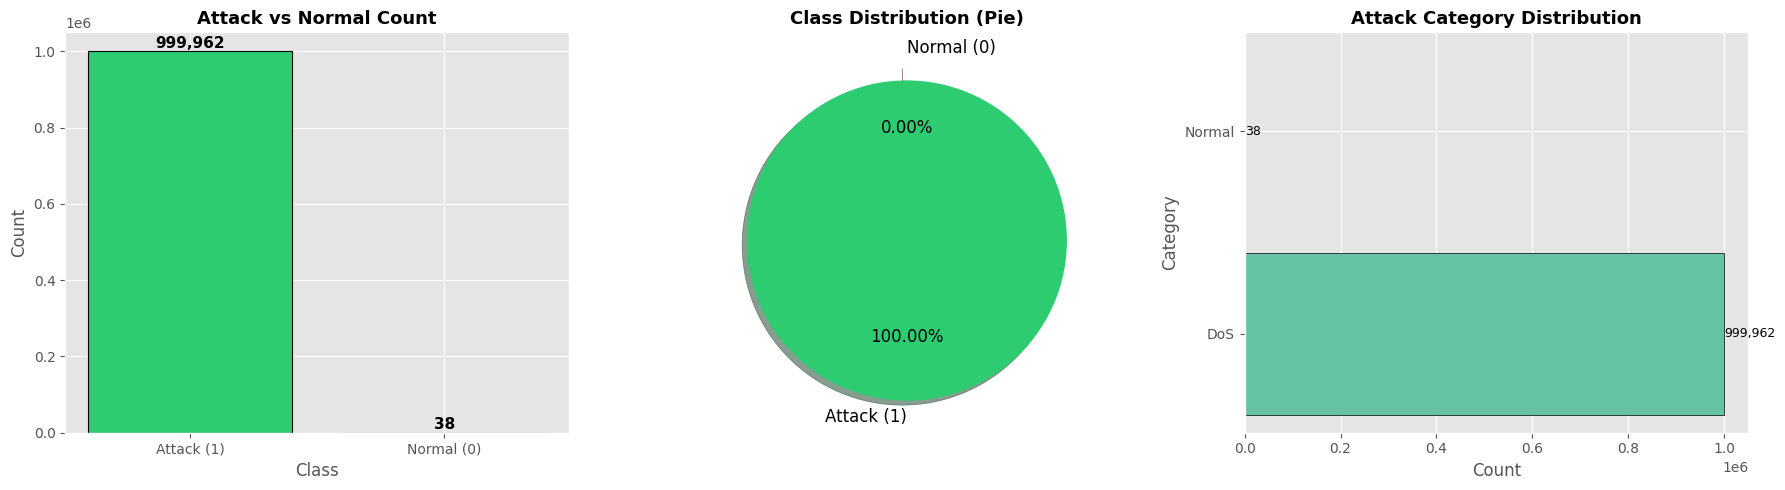

In [87]:
# ============================
# Section 6: Target Variable Distribution
# ============================

attack_counts = df['attack'].value_counts()
attack_pct    = df['attack'].value_counts(normalize=True) * 100

print("--- Target Variable: attack ---")
print(f"  0 (Normal) : {attack_counts.get(0, 0):>10,}  ({attack_pct.get(0, 0):.2f}%)")
print(f"  1 (Attack) : {attack_counts.get(1, 0):>10,}  ({attack_pct.get(1, 0):.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Count Plot ---
labels = {0: 'Normal (0)', 1: 'Attack (1)'}
colors_target = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    [labels.get(k, k) for k in attack_counts.index],
    attack_counts.values,
    color=colors_target, edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, attack_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Attack vs Normal Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')

# --- Plot 2: Pie Chart ---
axes[1].pie(attack_counts.values,
            labels=[labels.get(k, k) for k in attack_counts.index],
            autopct='%1.2f%%', colors=colors_target,
            startangle=90, explode=[0.05]*len(attack_counts),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

# --- Plot 3: Category Distribution ---
cat_counts = df['category'].value_counts()
axes[2].barh(cat_counts.index, cat_counts.values,
             color=sns.color_palette("Set2", len(cat_counts)), edgecolor='black', linewidth=0.5)
axes[2].set_title('Attack Category Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Category')
for i, (val, name) in enumerate(zip(cat_counts.values, cat_counts.index)):
    axes[2].text(val + 100, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

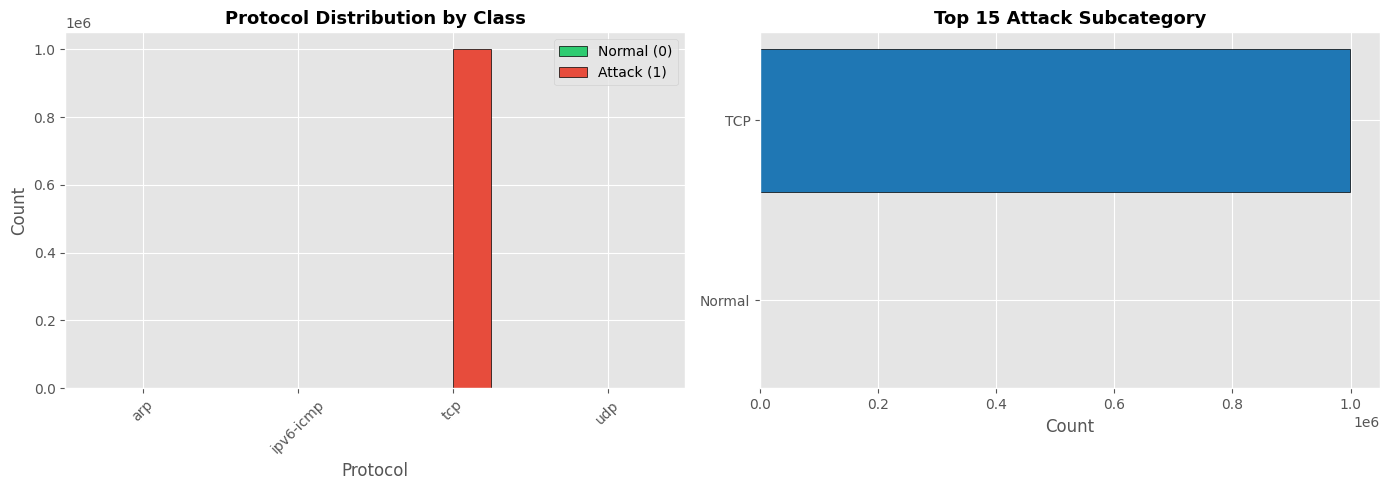

In [88]:
# Protocol distribution by attack class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proto_attack = df.groupby(['proto', 'attack']).size().unstack(fill_value=0)
proto_attack.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', linewidth=0.5)
axes[0].set_title('Protocol Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Count')
axes[0].legend(['Normal (0)', 'Attack (1)'])
axes[0].tick_params(axis='x', rotation=45)

# Subcategory distribution
sub_counts = df['subcategory'].value_counts().head(15)
axes[1].barh(sub_counts.index, sub_counts.values,
             color=sns.color_palette("tab20", len(sub_counts)), edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 15 Attack Subcategory', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Section 7: Feature Distribution Analysis
Visualizing histograms and KDE plots of numerical features - Normal vs Attack in different colors.

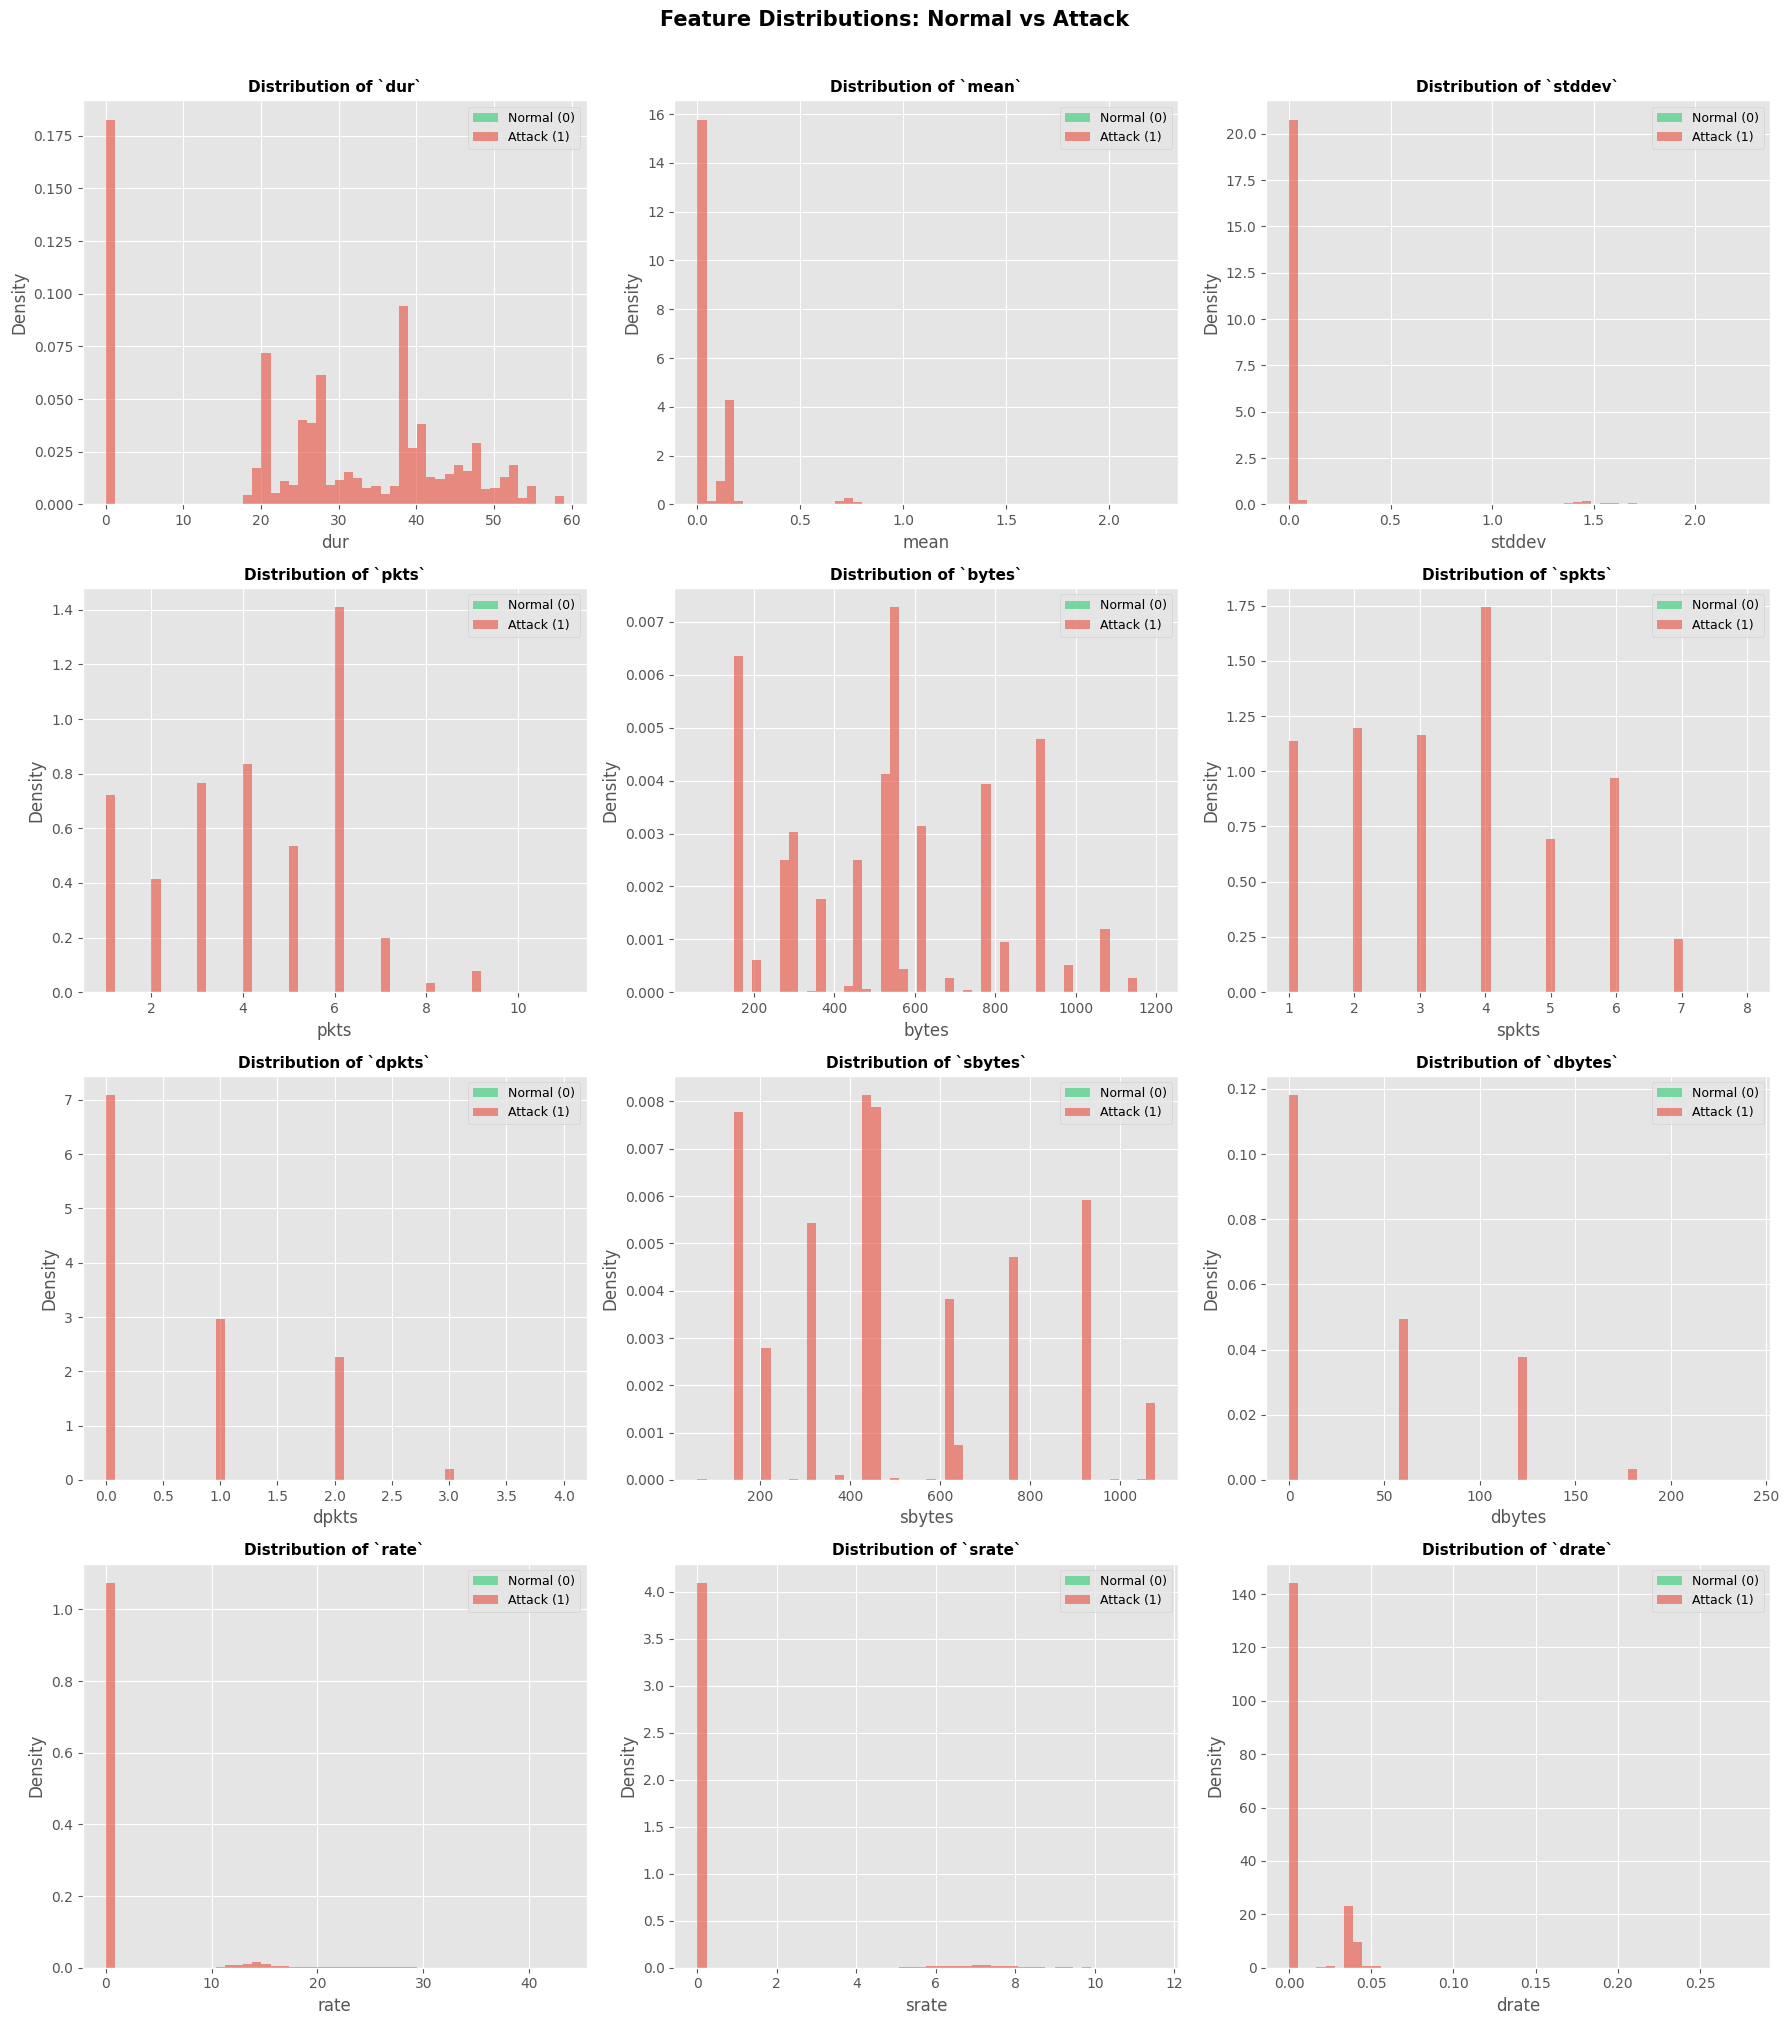

In [89]:
# ============================
# Section 7: Feature Distribution Analysis
# ============================

# Select key numerical features
key_num_features = ['dur', 'mean', 'stddev', 'pkts', 'bytes',
                    'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate']

# Select only features that exist
key_num_features = [f for f in key_num_features if f in df.columns]

# Take a sample (for large dataset)
sample = df.sample(min(20000, len(df)), random_state=42)

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(key_num_features[:12]):
    normal_data = sample[sample['attack'] == 0][col].dropna()
    attack_data = sample[sample['attack'] == 1][col].dropna()

    axes[i].hist(normal_data, bins=50, alpha=0.6, color='#2ecc71',
                 label='Normal (0)', density=True, edgecolor='none')
    axes[i].hist(attack_data, bins=50, alpha=0.6, color='#e74c3c',
                 label='Attack (1)', density=True, edgecolor='none')
    axes[i].set_title(f'Distribution of `{col}`', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

# Hide remaining axes
for j in range(len(key_num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Normal vs Attack', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

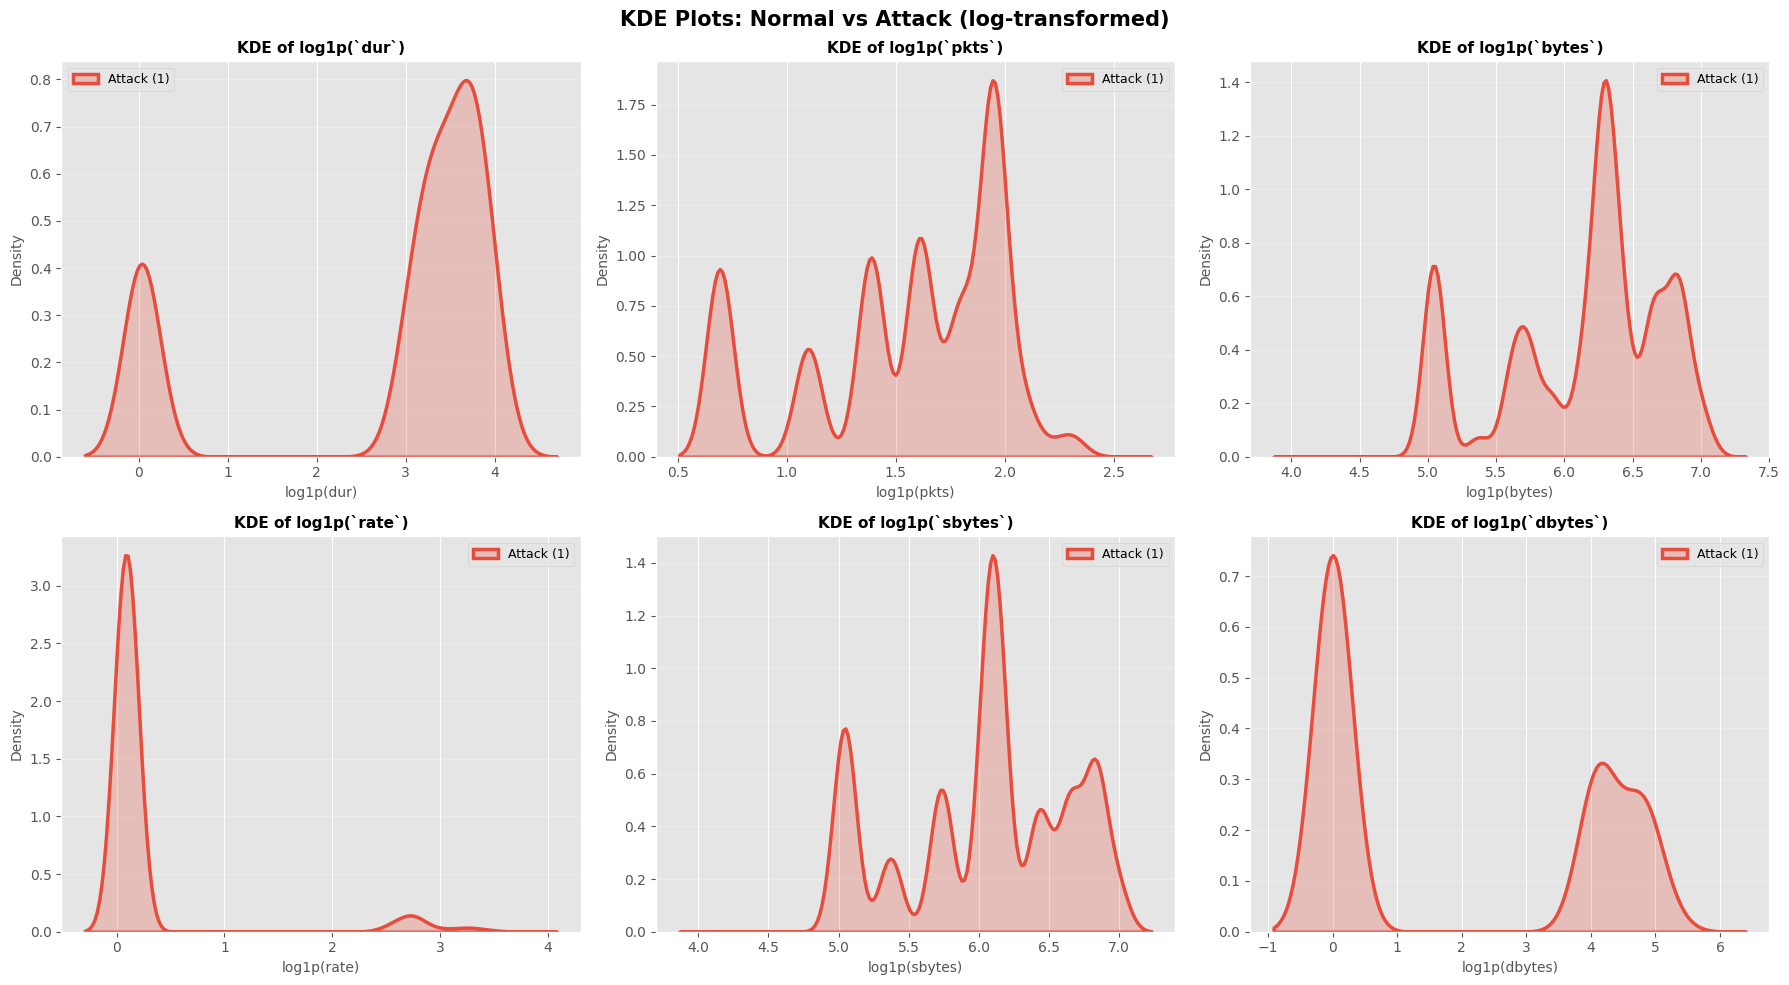

In [90]:
# KDE Plots - Normal vs Attack (using seaborn.kdeplot - robust version)

# If sample was not created in the previous cell, create it here
if 'sample' not in dir():
    sample = df.sample(min(20000, len(df)), random_state=42)

kde_features = ['dur', 'pkts', 'bytes', 'rate', 'sbytes', 'dbytes']
kde_features = [f for f in kde_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(kde_features[:6]):
    ax = axes[i]

    # Separate Normal and Attack data
    normal_data = sample[sample['attack'] == 0][col].dropna()
    attack_data = sample[sample['attack'] == 1][col].dropna()

    # Keep only positive values and apply log1p transform
    normal_log = np.log1p(normal_data.clip(lower=0))
    attack_log = np.log1p(attack_data.clip(lower=0))

    # Variance check — KDE fails if values are constant
    plotted = False
    if normal_log.std() > 1e-6 and len(normal_log) > 1:
        sns.kdeplot(normal_log, ax=ax, color='#2ecc71', linewidth=2.5,
                    label='Normal (0)', fill=True, alpha=0.25, warn_singular=False)
        plotted = True
    if attack_log.std() > 1e-6 and len(attack_log) > 1:
        sns.kdeplot(attack_log, ax=ax, color='#e74c3c', linewidth=2.5,
                    label='Attack (1)', fill=True, alpha=0.25, warn_singular=False)
        plotted = True

    if not plotted:
        ax.text(0.5, 0.5, 'Insufficient variance\nfor KDE',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=11, color='gray')

    ax.set_title(f'KDE of log1p(`{col}`)', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'log1p({col})', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('KDE Plots: Normal vs Attack (log-transformed)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8: Correlation Heatmap
Calculating the correlation matrix for numerical features and visualizing it with a heatmap

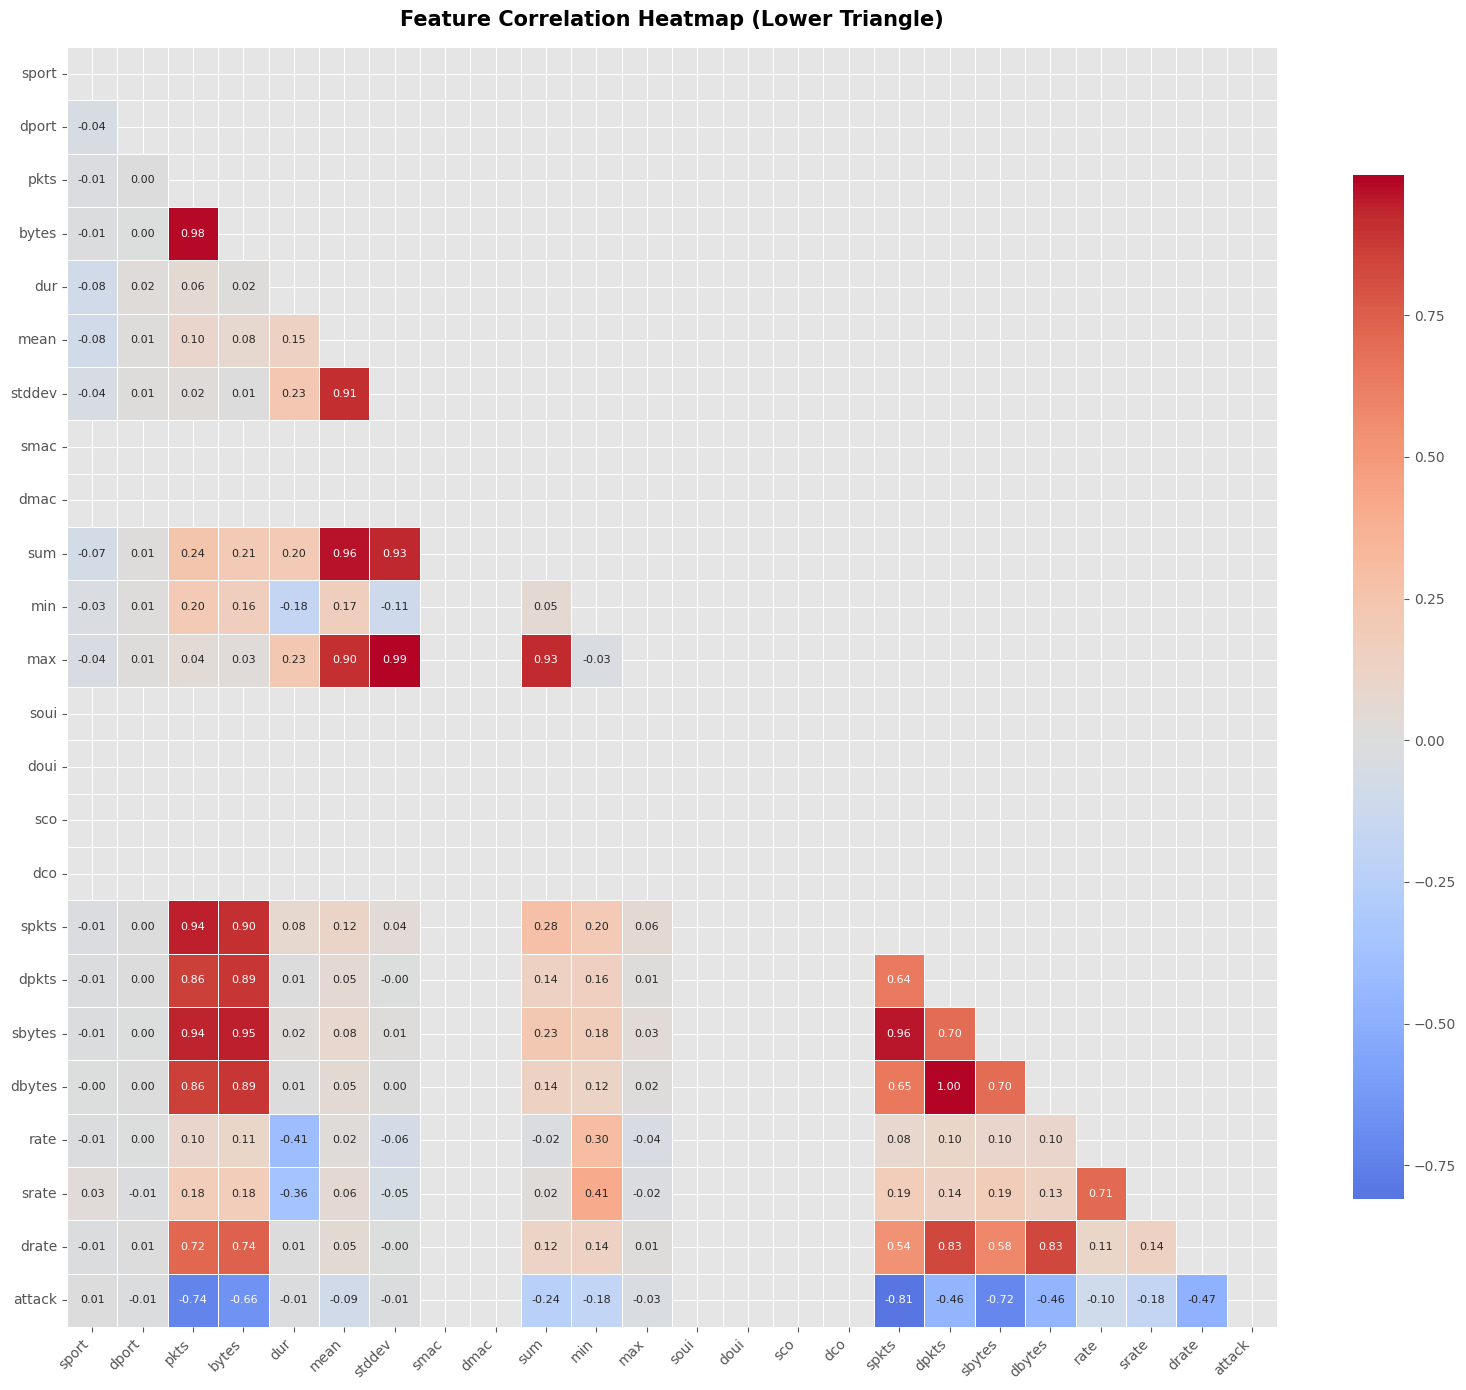

In [91]:
# ============================
# Section 8: Correlation Heatmap
# ============================

# Numerical columns select
corr_cols = [c for c in num_cols if c not in ['pkSeqID', 'stime', 'ltime', 'seq']]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [92]:
# Top highly correlated feature pairs
print("--- Top 15 Highly Correlated Feature Pairs (|corr| > 0.7) ---")
corr_pairs = (corr_matrix
              .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs['Abs Corr'] = corr_pairs['Correlation'].abs()
top_corr = corr_pairs.sort_values('Abs Corr', ascending=False)
print(top_corr[top_corr['Abs Corr'] > 0.7].to_string(index=False))

--- Top 15 Highly Correlated Feature Pairs (|corr| > 0.7) ---
Feature 1 Feature 2  Correlation  Abs Corr
   dbytes     dpkts       0.9978    0.9978
      max    stddev       0.9934    0.9934
    bytes      pkts       0.9827    0.9827
      sum      mean       0.9635    0.9635
   sbytes     spkts       0.9621    0.9621
   sbytes     bytes       0.9472    0.9472
    spkts      pkts       0.9441    0.9441
   sbytes      pkts       0.9407    0.9407
      sum    stddev       0.9310    0.9310
      max       sum       0.9252    0.9252
   stddev      mean       0.9091    0.9091
      max      mean       0.9028    0.9028
    spkts     bytes       0.9004    0.9004
   dbytes     bytes       0.8897    0.8897
    dpkts     bytes       0.8881    0.8881
    dpkts      pkts       0.8607    0.8607
   dbytes      pkts       0.8602    0.8602
    drate     dpkts       0.8321    0.8321
    drate    dbytes       0.8300    0.8300
   attack     spkts      -0.8095    0.8095
    drate     bytes       0.7389   

---
## Section 9: Outlier Detection
Detecting and visualizing outliers using Boxplot and IQR method.

In [93]:
# ============================
# Section 9: Outlier Detection
# ============================

# Counting outliers using the IQR method
outlier_features = ['dur', 'pkts', 'bytes', 'rate', 'mean', 'stddev',
                    'spkts', 'dpkts', 'sbytes', 'dbytes', 'srate', 'drate']
outlier_features = [f for f in outlier_features if f in df.columns]

print("--- IQR-based Outlier Detection ---")
outlier_summary = {}
for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Lower Fence': lower, 'Upper Fence': upper,
                            'Outlier Count': n_outliers, 'Outlier %': pct}
    print(f"  {col:<12}: {n_outliers:>8,} outliers  ({pct:.2f}%)")

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

--- IQR-based Outlier Detection ---
  dur         :        0 outliers  (0.00%)
  pkts        :      108 outliers  (0.01%)
  bytes       :       43 outliers  (0.00%)
  rate        :   71,504 outliers  (7.15%)
  mean        :   51,302 outliers  (5.13%)
  stddev      :   63,348 outliers  (6.33%)
  spkts       :       51 outliers  (0.01%)
  dpkts       :   16,130 outliers  (1.61%)
  sbytes      :       49 outliers  (0.00%)
  dbytes      :   16,135 outliers  (1.61%)
  srate       :   55,764 outliers  (5.58%)
  drate       :  201,545 outliers  (20.15%)


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
dur,20.2032,39.7158,19.5126,-9.0657,68.9846,0.0000,0.0000
pkts,3.0000,6.0000,3.0000,-1.5000,10.5000,108.0000,0.0108
bytes,308.0000,770.0000,462.0000,-385.0000,1463.0000,43.0000,0.0043
rate,0.0524,0.1544,0.1020,-0.1005,0.3073,71504.0000,7.1504
mean,0.0000,0.1337,0.1337,-0.2006,0.3343,51302.0000,5.1302
stddev,0.0000,0.0179,0.0179,-0.0269,0.0448,63348.0000,6.3348
spkts,2.0000,5.0000,3.0000,-2.5000,9.5000,51.0000,0.0051
dpkts,0.0000,1.0000,1.0000,-1.5000,2.5000,16130.0000,1.6130
sbytes,308.0000,642.0000,334.0000,-193.0000,1143.0000,49.0000,0.0049
dbytes,0.0000,60.0000,60.0000,-90.0000,150.0000,16135.0000,1.6135


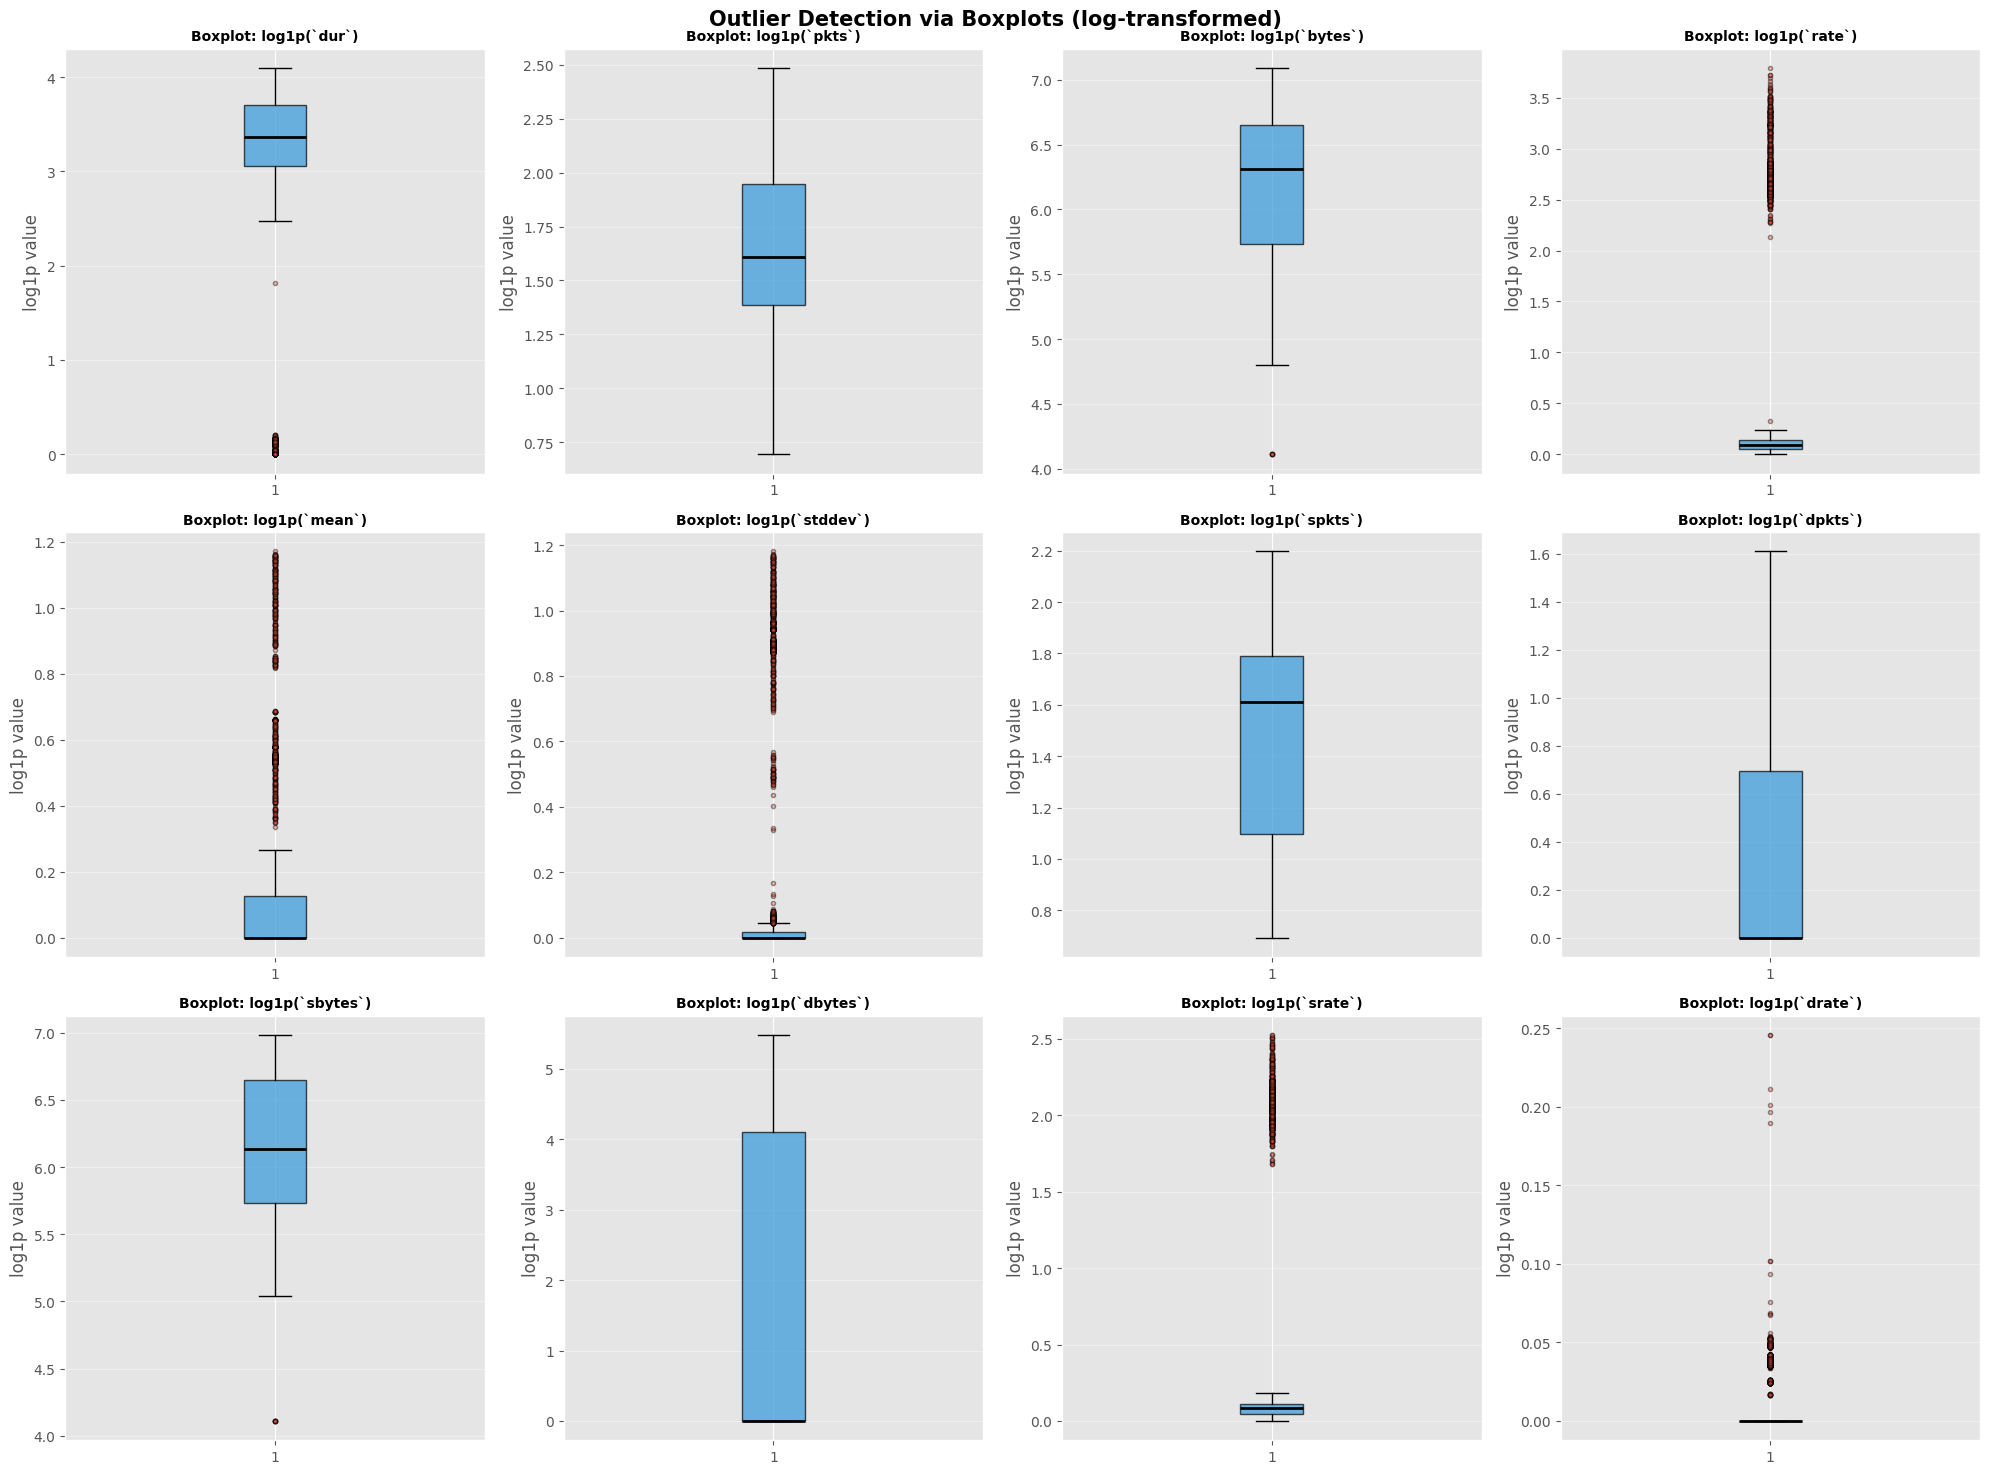

In [94]:
# Visualize outliers using Boxplot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(outlier_features[:12]):
    # Apply log transform
    data_log = np.log1p(sample[col].clip(lower=0))
    bp = axes[i].boxplot(data_log.dropna(), patch_artist=True,
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                                         markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Boxplot: log1p(`{col}`)', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('log1p value')
    axes[i].grid(axis='y', alpha=0.4)

# Hide remaining axes
for j in range(len(outlier_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection via Boxplots (log-transformed)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10: Feature Engineering & Encoding
Categorical features are being encoded and prepared for data modeling.

In [95]:
# ============================
# Section 10: Feature Engineering & Encoding
# ============================

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

df_encoded = df.copy()

# Step 1: Drop unnecessary columns
drop_cols = ['pkSeqID', 'stime', 'ltime', 'smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]
df_encoded.drop(columns=drop_cols, inplace=True)
print(f"✅ Dropped: {drop_cols}")

# Step 2: Convert sport, dport to numeric
for port_col in ['sport', 'dport']:
    if port_col in df_encoded.columns:
        df_encoded[port_col] = pd.to_numeric(df_encoded[port_col], errors='coerce').fillna(0).astype(int)
print("✅ sport, dport converted to numeric")

# Step 3: Encode categorical columns with LabelEncoder
low_card_cats = ['proto', 'flgs', 'state', 'category', 'subcategory']
low_card_cats = [c for c in low_card_cats if c in df_encoded.columns]

label_encode_map = {}
for col in low_card_cats:
    le = LabelEncoder()  # New encoder for each column
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str).fillna('unknown'))
    label_encode_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   [{col}] → {col}_enc  (unique: {df_encoded[col].nunique()})")

print()
print("✅ LabelEncoding complete!")

# Step 4: Extract last octet from saddr, daddr → IP
def extract_last_octet(ip_str):
    try:
        parts = str(ip_str).split('.')
        if len(parts) == 4:
            return int(parts[-1])
        return 0
    except (ValueError, AttributeError):
        return 0

for ip_col in ['saddr', 'daddr']:
    if ip_col in df_encoded.columns:
        df_encoded[ip_col + '_last_oct'] = df_encoded[ip_col].apply(extract_last_octet)
        print(f"   [{ip_col}] → {ip_col}_last_oct extracted")

print()
print(f"✅ Encoded DataFrame Shape: {df_encoded.shape}")
print(df_encoded.head(3))

✅ Dropped: ['pkSeqID', 'stime', 'ltime', 'smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
✅ sport, dport converted to numeric
   [proto] → proto_enc  (unique: 4)
   [flgs] → flgs_enc  (unique: 4)
   [state] → state_enc  (unique: 6)
   [category] → category_enc  (unique: 2)
   [subcategory] → subcategory_enc  (unique: 2)

✅ LabelEncoding complete!
   [saddr] → saddr_last_oct extracted
   [daddr] → daddr_last_oct extracted

✅ Encoded DataFrame Shape: (1000000, 33)
  flgs proto            saddr  sport          daddr  dport  pkts  bytes state  \
0  e g   tcp  192.168.100.149   7564  192.168.100.3     80     6    548   RST   
1  e g   tcp  192.168.100.149   7565  192.168.100.3     80     6    548   RST   
2  e g   tcp  192.168.100.149   7570  192.168.100.3     80     6    548   RST   

      seq     dur   mean  stddev    sum    min    max  spkts  dpkts  sbytes  \
0  252934 23.5333 0.1480  0.0027 0.2960 0.1453 0.1507      4      2     428   
1  252935 23.5333 0.1480  0.0027 0.2960 0.1453 0.1507

In [96]:
# Show encoded mapping
print("--- Label Encoding Mapping ---")
for col, mapping in label_encode_map.items():
    print(f"\n  [{col}]:")
    for k, v in list(mapping.items())[:10]:
        print(f"    '{k}' → {v}")

--- Label Encoding Mapping ---

  [proto]:
    'arp' → 0
    'ipv6-icmp' → 1
    'tcp' → 2
    'udp' → 3

  [flgs]:
    'e' → 0
    'e *' → 1
    'e g' → 2
    'e s' → 3

  [state]:
    'ACC' → 0
    'CON' → 1
    'INT' → 2
    'NRS' → 3
    'REQ' → 4
    'RST' → 5

  [category]:
    'DoS' → 0
    'Normal' → 1

  [subcategory]:
    'Normal' → 0
    'TCP' → 1


In [97]:
# Create final modeling-ready dataset
# Keep only numerical columns (including encoded)
final_num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
X = df_encoded[final_num_cols].drop(columns=['attack'], errors='ignore')
y = df_encoded['attack']

print(f"--- Final Dataset Ready for Modeling ---")
print(f"  Feature Matrix X shape : {X.shape}")
print(f"  Target Vector y shape  : {y.shape}")
print(f"  Target classes         : {y.unique()}")
print()
print(f"  Feature columns ({len(X.columns)}):")
for c in X.columns:
    print(f"    - {c}")

print()
print("✅ Data completely ready for modeling!")

--- Final Dataset Ready for Modeling ---
  Feature Matrix X shape : (1000000, 25)
  Target Vector y shape  : (1000000,)
  Target classes         : [1 0]

  Feature columns (25):
    - sport
    - dport
    - pkts
    - bytes
    - seq
    - dur
    - mean
    - stddev
    - sum
    - min
    - max
    - spkts
    - dpkts
    - sbytes
    - dbytes
    - rate
    - srate
    - drate
    - proto_enc
    - flgs_enc
    - state_enc
    - category_enc
    - subcategory_enc
    - saddr_last_oct
    - daddr_last_oct

✅ Data completely ready for modeling!


---
## EDA Summary

| Subject | Result |
|-------|--------|
| Dataset Source | UNSW 2018 IoT Botnet Dataset 9 |
| Target Variable | `attack` (0=Normal, 1=Attack) |
| Feature Count | 35 columns (original) |
| Missing Values | Check in Section 4 |
| Class Imbalance | See Section 6 |
| Outliers | See IQR analysis in Section 9 |
| Encoding Used | LabelEncoder for categoricals |
| Modeling Ready | `X` (features) and `y` (target) |

### Next Steps:
1. **Feature Selection** - Remove highly correlated features
2. **Scaling** - Apply StandardScaler / MinMaxScaler
3. **Imbalance Handling** - Use SMOTE or class_weight
4. **Model Training** - Use Random Forest, XGBoost, Neural Network, etc.
5. **Evaluation** - Check Accuracy, Precision, Recall, F1-Score, ROC-AUC